In [1]:
import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
import torch.utils.data as data

#ANFIS model, layers and functions

##Functions

In [2]:
gaussian2_params = ['mu', 'sigma']
def gaussian2(x, p):
    return torch.exp(-torch.pow((x - p[:, :, 0]), 2) / (2 * torch.pow(p[:, :, 1], 2)))

In [3]:
gaussian3_params = ['mu', 'sigma', 'f']
def gaussian3(x, p):
    return torch.exp(-p[:, :, 2] * torch.pow((x - p[:, :, 0]), 2) / (2 * torch.pow(p[:, :, 1], 2)))

In [4]:
def weighted_linear(x, c, w):
    return (x.matmul(c[:, :-1].transpose(0, 1)) + c[:, -1]).mul(w)

In [5]:
def sum(x):
    return torch.sum(x, dim=-1)

##Layers

###Fuzzify Layer

In [6]:
class FuzzifyLayer(nn.Module):
    '''
    Class that represents the first layer (fuzzification layer) of an ANFIS

    To initialize it:
        input_size : size of a single input
        init_rules : number of initial rules
        mf: function used as membership function
        params: list with parameter names
        x_train: training data set; this parameter its used to initialize the premises uniformly,
                 if it is not entered, the premises will be initialized randomly

    Other attributes:
        premises: array with the parameters used in each node of this layer
    '''
    def __init__(self, input_size, init_rules=3, mf=gaussian2, params=['mu', 'sigma'], x_train=[]):
        super(FuzzifyLayer, self).__init__()
        self.input_size = input_size
        self.init_rules = init_rules
        self.mf = mf
        self.params = params
        if x_train == []:
            prems = 2 * torch.rand(input_size, init_rules, len(params), dtype=torch.double) - 1
            prems[:,:,1] = (prems[:,:,1] + 1)/2 #Sigma stays positive
            self.premises = Parameter(prems, requires_grad=True)
        else:
            self.premises = Parameter(self.init_premises(x_train), requires_grad=True)

    def init_premises(self, x_train):
        premises = torch.zeros(self.input_size, self.init_rules, len(self.params), dtype=torch.double)
        if self.init_rules > 1:
            min = torch.min(x_train, dim=0).values
            max = torch.max(x_train, dim=0).values
            stp = (max - min) / (self.init_rules - 1)
            for i in range(self.input_size):
                h = torch.arange(min[i], max[i] + stp[i], stp[i])
                premises[i, :, 0] = h[:self.init_rules]
                premises[i, :, 1] = stp[i]/2
                if (len(self.params) == 3): premises[i, :, 2] = 2
        else:
            for i in range(self.input_size):
                premises[i, :, 0] = torch.mean(x_train[:, i])
                premises[i, :, 1] = torch.std(x_train[:, i])
                if (len(self.params) == 3): premises[i, :, 2] = 2
        return premises

    def forward(self, x):
        return self.mf(x.unsqueeze(x.dim()), self.premises)

    @property
    def premises_structure(self):
        print("Premises Structure:")
        for i in range(self.input_size):
            print(f"    x{i} parameters:")
            for j in range(self.init_rules):
                print(f"        rule {j + 1}:")
                [print(f"            {self.params[k]}: {self.premises[i, j, k]}") for k in range(len(self.params))]

###Firing Levels Layer

In [7]:
class FiringLevelsLayer(nn.Module):
    '''
    Class used to calculate firing levels and normalize them
    '''
    def __init__(self):
        super(FiringLevelsLayer, self).__init__()

    def forward(self, x, rules):
        if rules == 1:
            fls = x.prod(dim=x.dim()-2)
            fls = fls/torch.where(fls == 0, torch.tensor(1e-6), fls)
        else:
            sum = torch.sum(x.prod(dim=x.dim()-2), dim=1, keepdim=True)
            sum[sum == 0] = 1
            fls = x.prod(dim=x.dim()-2)/sum
        return fls

###Consequent Layer

In [8]:
class ConsequentLayer(nn.Module):
    '''
    Class that represents the fourth layer (consequent layer) of an ANFIS

    To initialize it:
        input_size : size of a single input
        init_rules : number of init_rules
        function : function used as a consequent function

    Other attributes:
        consequents: array with the parameters used in each node of this layer
    '''
    def __init__(self, input_size, init_rules=3, function=weighted_linear):
        super(ConsequentLayer, self).__init__()
        self.init_rules = init_rules
        self.input_size = input_size
        self.function = function
        self.consequents = Parameter(2 * torch.rand(init_rules, input_size + 1, dtype=torch.double) - 1, requires_grad=True)

    def forward(self, x, w):
        return self.function(x, self.consequents, w)

    @property
    def consequents_structure(self):
        print("Consequents Structure:")
        for i in range(self.init_rules):
            print(f"    rule {i + 1} consequent parameters: {self.consequents[i]}")

###Output Layer

In [9]:
class OutputLayer(nn.Module):
    '''
    Class that represents the fifth layer (output layer) of an ANFIS
    '''
    def __init__(self, function=sum):
        super(OutputLayer, self).__init__()
        self.function = function

    def forward(self, x):
        return self.function(x)

##ANFIS model

In [10]:
class Type3ANFIS(nn.Module):
    '''
    Class that represents a type3 ANFIS

    To initialize it:
        input_size : size of a single input
        init_rules : number of initial rules
        cf: function used as consequent function
        mf: function used as membership function
        of: function used to join the outputs of each of the rules
        mf_params: list with MF parameters namesr
        x_train: training data set; this parameter its used to initialize the premises uniformly,
                 if it is not entered, the premises will be initialized randomly
    '''
    def __init__(self, input_size, init_rules=3, cf=weighted_linear, mf=gaussian2, of=sum, mf_params=['mu', 'sigma'], x_train=[]):
        super(Type3ANFIS, self).__init__()
        self.input_size = input_size
        self.mf_params = mf_params
        if x_train == []:
            self.fuzzify_layer = FuzzifyLayer(input_size, init_rules, mf, mf_params)
        else:
            self.fuzzify_layer = FuzzifyLayer(input_size, init_rules, mf, mf_params, x_train)
        self.firing_levels_layer = FiringLevelsLayer()
        self.consequent_layer = ConsequentLayer(input_size, init_rules, cf)
        self.output_layer = OutputLayer(of)

    def forward(self, x):
        output = self.fuzzify_layer(x)
        output = self.consequent_layer(x, self.firing_levels_layer(output, self.rules))
        output = self.output_layer(output)
        return output

    def firing_levels(self, x):
        x = self.fuzzify_layer(x)
        fl = x.prod(dim=x.dim()-2)
        return fl

    def outputs_by_rule(self, x):
        output = self.fuzzify_layer(x)
        output = self.consequent_layer(x, self.firing_levels_layer(output, self.rules))
        return output

    @property
    def rules(self):
        return self.consequents.shape[0]

    @property
    def premises_structure(self):
        self.fuzzify_layer.premises_structure

    @property
    def premises(self):
        return self.fuzzify_layer.premises

    def set_premises(self, premises):
        self.fuzzify_layer.premises = premises

    @property
    def consequents_structure(self):
        self.consequent_layer.consequents_structure

    @property
    def consequents(self):
        return self.consequent_layer.consequents

    def set_consequents(self, consequents):
        self.consequent_layer.consequents = consequents

#Dataset for testing

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

In [12]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

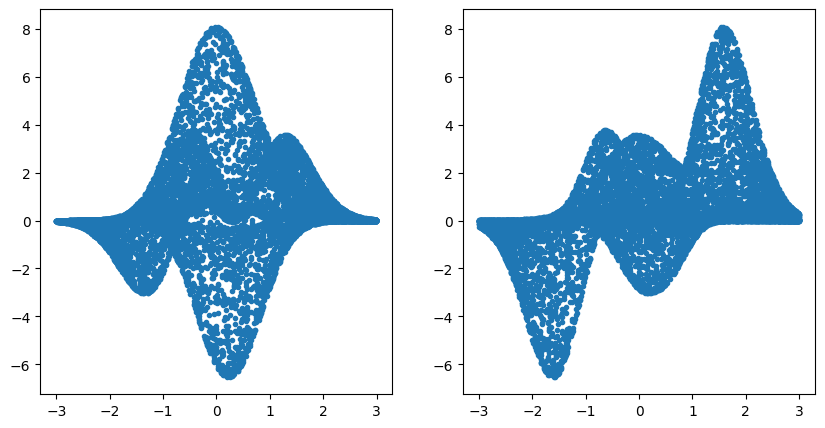

In [13]:
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(x0, z(x0,x1), '.')
ax[1].plot(x1, z(x0,x1), '.')
plt.show()

x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

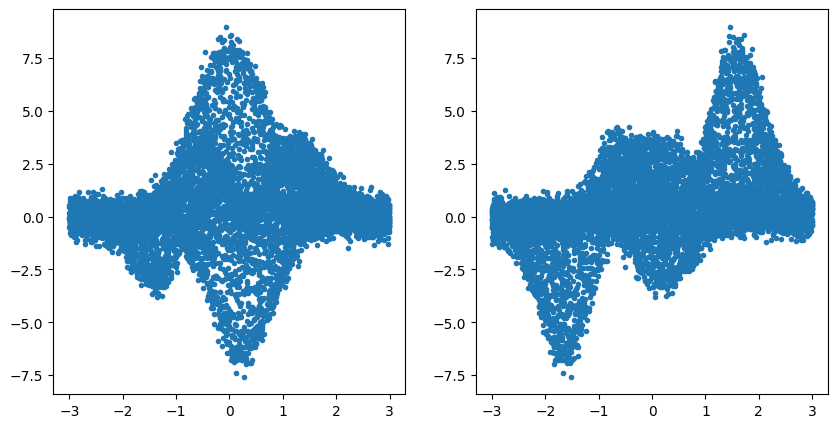

10000


In [14]:
e = np.random.normal(0,0.4,10000)
Y = z(x0,x1) + e

fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(x0, Y, '.')
ax[1].plot(x1, Y, '.')
plt.show()
print(len(Y))

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

vstack_test = np.vstack((x0,x1)).T
scaled_test = scaler.fit_transform(vstack_train)

In [16]:
test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 8, shuffle = True)

In [17]:
x_trainset = test_loader.dataset.tensors[0]
x_trainset

tensor([[0.4586, 0.1511],
        [0.0676, 0.8772],
        [0.5356, 0.5211],
        ...,
        [0.2992, 0.9263],
        [0.2835, 0.4654],
        [0.9229, 0.9431]], dtype=torch.float64)

In [18]:
ANFIStest_model = Type3ANFIS(x_trainset.shape[1], x_train=x_trainset)

In [19]:
ANFIStest_model.premises

Parameter containing:
tensor([[[0.0000, 0.2500],
         [0.5000, 0.2500],
         [1.0000, 0.2500]],

        [[0.0000, 0.2500],
         [0.5000, 0.2500],
         [1.0000, 0.2500]]], dtype=torch.float64, requires_grad=True)

In [20]:
ANFIStest_model.consequents

Parameter containing:
tensor([[0.3424, 0.8406, 0.0441],
        [0.2021, 0.0340, 0.7783],
        [0.8017, 0.0127, 0.9103]], dtype=torch.float64, requires_grad=True)

#SONFIS operators and OLS algorithm

##OLS

###Implementation

In [21]:
def OLS(ANFISmodel, loader, y, epochs, freezed):
    ep = 0
    while (ep < epochs):
        print("\n*******************EPOCH", ep+1, "*******************\n")
        #---CONSEQUENTS ESTIMATION---

        #needed tensors for consequents calculation
        x_train = test_loader.dataset.tensors[0]
        y_train = test_loader.dataset.tensors[1] #targets
        new_consequents = ANFISmodel.consequents.data
        xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train

        #normalized firing levels
        if ANFISmodel.rules == 1: #if there is one rule (Nx1 tensor), torch normalization doesnt work correctly
            fls = ANFISmodel.firing_levels(x_train)
            fls = fls/fls
        else:
            #fls = torch.nn.functional.normalize(ANFISmodel.firing_levels(x_train), p=1, dim=-1) #normalized firing_levels
            sum = torch.sum(ANFISmodel.firing_levels(x_train), dim=1, keepdim=True)
            sum[sum == 0] = 1
            fls = ANFISmodel.firing_levels(x_train)/sum

        #iterates by rule
        for i in range(ANFISmodel.rules):
            if freezed[i] == 0:
                #firing_levels diagonal matrix
                fls_diag = torch.diag(fls[:, i])

                #new consequents
                #new_consequents[i], _, _, _ = torch.linalg.lstsq(xe.t() @ fls_diag @ xe, xe.t() @ fls_diag @ y_train)
                new_consequents[i], _, _, _ = torch.linalg.lstsq(fls_diag @ xe, y_train)

        ANFISmodel.set_consequents(Parameter(new_consequents, requires_grad=True))

        #---PREMISES ESTIMATION---

        #needed tensors for consequents calculation
        pred = ANFISmodel(x_train) #models prediction

        #mse and premises gradients calculation with pytorchs backward function
        mse = nn.functional.mse_loss(pred, y_train)
        mse.backward()

        #alpha calculation (with premises gradients obtained before with mse.backward())
        alpha = y / torch.sqrt(torch.sum(torch.pow(ANFISmodel.premises.grad, 2)))

        #premises extracted
        current_premises = ANFISmodel.premises.data
        vs = current_premises[:,:,0].t()
        sigmas = current_premises[:,:,1].t()
        new_vs = torch.zeros_like(vs)
        new_sigmas = torch.zeros_like(sigmas)

        #iterates by rule
        for i in range(ANFISmodel.rules):
            if freezed[i] == 0:
                #mu
                A = 4*alpha*(1/torch.pow(sigmas[i], 2))*(x_train - vs[i])
                wk = fls[:,i].unsqueeze(0).t()
                fk = ANFISmodel.outputs_by_rule(x_train)[:,i]
                zk = ((fk-pred)*(y_train-pred)).unsqueeze(0).t()

                new_vs[i] = torch.sum(A*wk*zk, dim=0)

                #sigma
                B = 4*alpha*(1/torch.pow(sigmas[i], 3))*torch.pow((x_train - vs[i]), 2)

                new_sigmas[i] = torch.sum(B*wk*zk, dim=0)

        #Premises update
        current_premises[:, :, 0] += new_vs.t()
        current_premises[:, :, 1] += new_sigmas.t()

        #Parameters set on ANFISmodel
        ANFISmodel.set_premises(Parameter(current_premises, requires_grad=True))

        ep = ep+1

In [23]:
def OLS(ANFISmodel, loader, y, epochs, ):
    ep = 0
    while (ep < epochs):
        print("\n*******************EPOCH", ep+1, "*******************\n")
        #---NEEDED TENSORS---
        #dataset
        x_train = test_loader.dataset.tensors[0]
        y_train = test_loader.dataset.tensors[1] #targets

        #normalized firing levels
        if ANFISmodel.rules == 1: #if there is one rule (Nx1 tensor), torch normalization doesnt work correctly
            fls = ANFISmodel.firing_levels(x_train)
            fls = fls/fls
        else:
            #fls = torch.nn.functional.normalize(ANFISmodel.firing_levels(x_train), p=1, dim=-1) #normalized firing_levels
            sum = torch.sum(ANFISmodel.firing_levels(x_train), dim=1, keepdim=True)
            sum[sum == 0] = 1
            fls = ANFISmodel.firing_levels(x_train)/sum

        #---PREMISES ESTIMATION---

        #needed tensors for consequents calculation
        pred = ANFISmodel(x_train) #models prediction

        #mse and premises gradients calculation with pytorchs backward function
        mse = nn.functional.mse_loss(pred, y_train)
        mse.backward()

        #alpha calculation (with premises gradients obtained before with mse.backward())
        alpha = y / torch.sqrt(torch.sum(torch.pow(ANFISmodel.premises.grad, 2)))

        #premises extracted
        current_premises = ANFISmodel.premises.data
        vs = current_premises[:,:,0].t()
        sigmas = current_premises[:,:,1].t()
        new_vs = torch.zeros_like(vs)
        new_sigmas = torch.zeros_like(sigmas)

        #iterates by rule
        for i in range(ANFISmodel.rules):
            #mu
            A = 4*alpha*(1/torch.pow(sigmas[i], 2))*(x_train - vs[i])
            wk = fls[:,i].unsqueeze(0).t()
            fk = ANFISmodel.outputs_by_rule(x_train)[:,i]
            zk = ((fk-pred)*(y_train-pred)).unsqueeze(0).t()

            new_vs[i] = torch.sum(A*wk*zk, dim=0)

            #sigma
            B = 4*alpha*(1/torch.pow(sigmas[i], 3))*torch.pow((x_train - vs[i]), 2)

            new_sigmas[i] = torch.sum(B*wk*zk, dim=0)

        #Premises update
        current_premises[:, :, 0] += new_vs.t()
        current_premises[:, :, 1] += new_sigmas.t()

        #Parameters set on ANFISmodel
        ANFISmodel.set_premises(Parameter(current_premises, requires_grad=True))


        #---CONSEQUENTS ESTIMATION---

        new_consequents = torch.zeros_like(ANFISmodel.consequents.data)
        xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train

        #iterates by rule
        for i in range(ANFISmodel.rules):
            #firing_levels diagonal matrix
            fls_diag = torch.diag(fls[:, i])
            #fls_diag = fls[:, i].repeat(ANFISmodel.input_size + 1, 1)

            #new consequents
            #new_consequents[i], _, _, _ = torch.linalg.lstsq(xe.t() @ fls_diag @ xe, xe.t() @ fls_diag @ y_train)
            new_consequents[i], _, _, _ = torch.linalg.lstsq(fls_diag @ xe, fls_diag @ y_train)
            #new_consequents[i], _, _, _ = torch.linalg.lstsq((xe.t() * fls_diag).t(), y_train)

        ANFISmodel.set_consequents(Parameter(new_consequents, requires_grad=True))

        ep = ep+1

###Testing

In [24]:
ANFIStest_model = Type3ANFIS(x_trainset.shape[1])

In [25]:
print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
for i in range(10):
    print("\n----------------------")
    print(f"\nIteration {i}")
    OLS(ANFIStest_model, test_loader, 0.01, 2)
    print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
    print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
    print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
    print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")

ANFIStest_model premises: tensor([[[-0.8629,  0.2672],
         [-0.6347,  0.9279],
         [-0.2694,  0.5729]],

        [[ 0.6929,  0.3608],
         [-0.5014,  0.2055],
         [-0.7017,  0.1507]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[ 0.5107,  0.5539,  0.9949],
        [ 0.5292,  0.4167,  0.5016],
        [-0.9413,  0.8405, -0.1937]], dtype=torch.float64)
ANFIStest_model consequents.grad: None

----------------------

Iteration 0

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************

ANFIStest_model premises: tensor([[[ 39.1717, 233.6517],
         [-14.7634,  14.2982],
         [  6.5086,   8.9466]],

        [[ 15.9401,   9.7194],
         [ 81.5402, 468.4993],
         [ 23.0108,  53.2490]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[ 0.7171,  2.5698, -1.2829],
        [ 0.6859,  2.5511, -1.2585],
        [-1.7905, -1.8160, 

KeyboardInterrupt: 

In [24]:
print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
for i in range(10):
    print("\n----------------------")
    print(f"\nIteration {i}")
    OLS(ANFIStest_model, test_loader, 0.001)
    print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
    print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
    print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
    print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")

ANFIStest_model premises: tensor([[[-1.5592e+08, -3.7733e+08],
         [ 2.9935e+09, -3.2269e+09],
         [-7.8923e+06,  7.7023e+05]],

        [[ 3.5898e+08,  8.0072e+08],
         [-8.1300e+08,  1.4645e+09],
         [ 7.3821e+05, -9.3796e+05]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[ 0.6573,  2.5168, -1.2412],
        [ 0.6573,  2.5168, -1.2412],
        [ 0.6573,  2.5168, -1.2412]], dtype=torch.float64)
ANFIStest_model consequents.grad: tensor([[ 4.0111e-10, -2.0585e-10, -6.2797e-16],
        [-4.0111e-10,  2.0585e-10, -4.0332e-17],
        [-1.1005e-29,  4.3653e-30,  7.3946e-35]], dtype=torch.float64)

----------------------

Iteration 0
ANFIStest_model premises: tensor([[[-2.3864e+08, -3.1488e+08],
         [ 2.9964e+09, -3.2252e+09],
         [-7.8923e+06,  7.7023e+05]],

        [[ 4.5428e+08,  7.1855e+08],
         [-7.9165e+08,  1.4910e+09],
         [ 7.3821e+05, -9.3796e+05]]], dtype=torch.float64)
ANFIStest_model 

###Some future considerations

1.   It may be usefull to implement tran/valid set partition
2.   



##GrowNet

###Implementation

In [220]:
def GrowNet(ANFISmodel, loader, ages, Ngrow, dGrow, freezed):
    first_batch = True
    for x_batch, y_batch in loader:
        #Max firing levels are obtenined
        firing_levels = ANFISmodel.firing_levels(x_batch)
        max_fl = torch.max(firing_levels, dim=1)

        #Boolean mask to filter the samples
        dGrow_mask = (max_fl.values <= dGrow**ANFISmodel.input_size)

        #Necesary tensors are defined on the first iteration
        if first_batch:
            bad_samples = torch.tensor([])
            best_bs_rules = torch.tensor([], dtype=torch.int)
            first_batch = False

        #The samples are extracted by concatenating tensors (which are filtered by the mask)
        bad_samples = torch.cat((bad_samples, x_batch[dGrow_mask]), dim=0)
        best_bs_rules = torch.cat((best_bs_rules, max_fl.indices[dGrow_mask]), dim=0)

    #Ngrow parameter filter
    unique_rules, counts = torch.unique(best_bs_rules, return_counts=True)
    Ngrow_mask = (counts > Ngrow)

    indices_to_keep = torch.isin(best_bs_rules, unique_rules[Ngrow_mask]).nonzero().squeeze()

    bad_samples = bad_samples[indices_to_keep]
    best_bs_rules = best_bs_rules[indices_to_keep]

    #return False if ANFISmodel is not modified
    if bad_samples.size(0) == 0:
        return False, ages, freezed

    #a list of masks called "rules" is created to calculate the necessary means and stds
    rules = [best_bs_rules == value for value in torch.unique(best_bs_rules)]

    #means and stds by rule are calculated
    means = torch.stack([(bad_samples[rule].mean(dim=0)) for rule in rules])
    stds = torch.stack([(bad_samples[rule].std(dim=0)) for rule in rules])

    #Premises and consequents modifications to add a new rule
    new_premises = torch.stack([means.t(), stds.t()], dim=2)
    ANFISmodel.set_premises(Parameter(torch.cat([ANFISmodel.premises.data, new_premises], dim=1), requires_grad=True))

    new_consequents = 2 * torch.rand(new_premises.size(1), ANFISmodel.input_size + 1) - 1
    ANFISmodel.set_consequents(Parameter(torch.cat([ANFISmodel.consequents.data, new_consequents]), requires_grad=True))

    #New rules age
    freezed = torch.cat([freezed, torch.zeros(new_premises.shape[1])])
    ages = torch.cat([ages, torch.zeros(new_premises.shape[1], dtype=torch.bool)])

    #return True if ANFISmodel is modified
    return True, ages, freezed

###Testing

In [26]:
ANFIStest_model = Type3ANFIS(x_trainset.shape[1], init_rules=1)

In [27]:
ages = torch.zeros(ANFIStest_model.premises.shape[1])
Ngrow = 1000
dGrow = 1.7

In [28]:
print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
for i in range(7):
    print("\n\n----------------------")
    print(f"\n\nIteration {i}")
    did_change, ages = GrowNet(ANFIStest_model, test_loader, ages, Ngrow, dGrow)
    if did_change:
        print("ANFIS Growing:")
        print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
        print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
        print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
        print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
    else:
        print("NOT GROWING......")

ANFIStest_model premises: tensor([[[-0.9739,  0.3669]],

        [[ 0.3233,  0.6149]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[-0.5882,  0.4899, -0.6547]], dtype=torch.float64)
ANFIStest_model consequents.grad: None


----------------------


Iteration 0
ANFIS Growing:
ANFIStest_model premises: tensor([[[-0.9739,  0.3669],
         [ 0.4989,  0.2876]],

        [[ 0.3233,  0.6149],
         [ 0.5015,  0.2891]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[-0.5882,  0.4899, -0.6547],
        [-0.3989, -0.9290, -0.5017]], dtype=torch.float64)
ANFIStest_model consequents.grad: None


----------------------


Iteration 1
ANFIS Growing:
ANFIStest_model premises: tensor([[[-0.9739,  0.3669],
         [ 0.4989,  0.2876],
         [ 0.4989,  0.2876]],

        [[ 0.3233,  0.6149],
         [ 0.5015,  0.2891],
         [ 0.5015,  0.2891]]], dtype=torch.float64)
ANFIStest_model premises.gra

In [29]:
ages

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

##Split Sub-netwok

###Implementation

In [221]:
def SplitSubNetwork(ANFISmodel, loader, ages, Nsplit, eSplit, freezed):
    first_batch = True
    for x_batch, y_batch in loader:
        #Max firing levels are obtenined
        firing_levels = ANFISmodel.firing_levels(x_batch)
        max_fl = torch.max(firing_levels, dim=1)

        #Necesary tensors are defined on the first iteration
        if first_batch:
            samples = torch.tensor([])
            samples_output = torch.tensor([])
            best_rules = torch.tensor([], dtype=torch.int)
            first_batch = False

        #The best rules are extracted by concatenating tensors
        samples = torch.cat((samples, x_batch), dim=0)
        samples_output = torch.cat((samples_output, y_batch), dim=0)
        best_rules = torch.cat((best_rules, max_fl.indices), dim=0)

    #Nsplit parameter filter
    unique_rules, counts = torch.unique(best_rules, return_counts=True)
    Nsplit_mask = (counts > Nsplit)

    indices_to_keep = torch.isin(best_rules, unique_rules[Nsplit_mask]).nonzero().squeeze()

    samples = samples[indices_to_keep]
    samples_output = samples_output[indices_to_keep]
    best_rules = best_rules[indices_to_keep]

    #the rules from best_rules tensor are extracted
    unique_rules = torch.unique(best_rules)

    #MSE is calculated by rule
    mse_values = torch.stack([torch.pow((samples_output[best_rules == rule] - ANFISmodel(samples[best_rules == rule])), 2).mean(dim=0) for rule in unique_rules])

    #eSplit parameter filter
    eSplit_mask = (mse_values > eSplit)

    #return Flase if ANFISmodel is not modified
    if ((samples.shape[0] == 0) | (unique_rules[eSplit_mask].shape[0] == 0)):
        return False, ages, freezed

    #loop to split each rule one by one and generate the new ones
    new_premises = ANFISmodel.premises.data #new_premises starts being a copy of the current premises
    new_consequents = ANFISmodel.consequents.data #same thing with consequents
    for rule in list(torch.flip(unique_rules[eSplit_mask], [0]).long()): #the iteration is performed on a list with the rules in descending order
        #the selected premise is extracted from the new_premises tensor and placed into the to_split tensor
        new_premises = torch.cat([new_premises[:, :rule, :], new_premises[:, rule+1:, :]], dim=1)
        to_split = ANFISmodel.premises.data[:, rule:rule+1, :].clone()

        #the new ones are generated
        split1 = torch.cat([(to_split[:,:,0] - to_split[:,:,1]/2).unsqueeze(1), (to_split[:,:,1]/2).unsqueeze(1)], dim=2)
        split2 = torch.cat([(to_split[:,:,0] + to_split[:,:,1]/2).unsqueeze(1), (to_split[:,:,1]/2).unsqueeze(1)], dim=2)

        #both are inserted on the new premises tensor
        new_premises = torch.cat([new_premises, torch.cat([split1, split2], dim=1)], dim=1)

        #the corresponding consequent is taken away
        new_consequents = torch.cat([new_consequents[:rule, :], new_consequents[rule+1:, :]], dim=0)

        #two new consequents are added
        new_consequents = torch.cat([new_consequents, 2 * torch.rand(2, ANFISmodel.input_size + 1) - 1], dim=0)

        #same with ages tensor
        ages = torch.cat([ages[:rule], ages[rule+1:]]) #the corresponding rule is taken away
        freezed = torch.cat([freezed[:rule], freezed[rule+1:]])
        ages = torch.cat([ages, torch.zeros(2, dtype=torch.bool)]) #the new ones are added
        freezed = torch.cat([freezed, torch.zeros(2)])

    #after the loop, the new parameters are set
    ANFISmodel.set_premises(Parameter(new_premises, requires_grad=True))
    ANFISmodel.set_consequents(Parameter(new_consequents, requires_grad=True))

    #return True if ANFISmodel is modified
    return True, ages, freezed

###Testing

In [31]:
ANFIStest_model = Type3ANFIS(x_trainset.shape[1])

In [32]:
ages = torch.zeros(ANFIStest_model.premises.shape[1])
Nsplit = 800
eSplit = 3.8

In [33]:
print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
for i in range(7):
    print("\n\n----------------------")
    print(f"\n\nIteration {i}")
    did_change, ages = SplitSubNetwork(ANFIStest_model, test_loader, ages, Nsplit, eSplit)
    if did_change:
        print("ANFIS Split:")
        print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
        print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
        print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
        print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
    else:
        print("NOT SPLIT......")

ANFIStest_model premises: tensor([[[ 0.4654,  0.2885],
         [-0.5150,  0.2195],
         [ 0.1758,  0.7661]],

        [[-0.4277,  0.3780],
         [ 0.3560,  0.3773],
         [ 0.7109,  0.4380]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[-0.5980,  0.3184,  0.6859],
        [-0.2542,  0.4031, -0.2499],
        [ 0.2989,  0.0292,  0.8206]], dtype=torch.float64)
ANFIStest_model consequents.grad: None


----------------------


Iteration 0
ANFIS Split:
ANFIStest_model premises: tensor([[[ 0.4654,  0.2885],
         [-0.5150,  0.2195],
         [-0.2072,  0.3830],
         [ 0.5589,  0.3830]],

        [[-0.4277,  0.3780],
         [ 0.3560,  0.3773],
         [ 0.4919,  0.2190],
         [ 0.9299,  0.2190]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[-0.5980,  0.3184,  0.6859],
        [-0.2542,  0.4031, -0.2499],
        [ 0.3206, -0.7972,  0.6812],
        [ 0.6381, -0.0044, 

##VanishNet

###Implementation

In [247]:
def VanishSubNetwork(ANFISmodel, loader, ages, Nvanish, lVanish, last_best_rules, freezed):
    first_batch = True
    for x_batch, y_batch in loader:
        #Max firing levels are obtenined
        firing_levels = ANFISmodel.firing_levels(x_batch)
        max_fl = torch.max(firing_levels, dim=1)

        #Necesary tensors are defined on the first iteration
        if first_batch:
            best_rules = torch.tensor([], dtype=torch.int)
            first_batch = False

        #the best_rules by sample are extracted
        best_rules = torch.cat((best_rules, max_fl.indices), dim=0)

    #Important info for net operations
    unique_rules, counts = torch.unique(best_rules, return_counts=True)
    all_rules = torch.arange(ANFISmodel.rules)

    #tensor with te amounts of samples modeled for each rule (including those who dont model any sample)
    total_counts = torch.zeros(ANFISmodel.rules, dtype=torch.int64)
    total_counts[unique_rules] = counts

    #if there is no changes with the modeled samples or there is no last_best_rules (first iteration of VanishNet operator)
    if torch.equal(best_rules, last_best_rules) | torch.equal(last_best_rules, torch.tensor([-1])):
        #ages update
        ages += 1
    else:
        #last best rules are inspected (only the ones that appeared in the current iteration)
        last_unique_rules, last_counts = torch.unique(last_best_rules, return_counts=True)
        last_total_counts = torch.zeros(ANFISmodel.rules, dtype=torch.int64)
        last_total_counts[last_unique_rules[last_unique_rules < ANFISmodel.rules]] = last_counts[last_unique_rules < ANFISmodel.rules]

        #rules categorization
        improved_rules = all_rules[last_total_counts < total_counts]
        not_improved_rules = all_rules[last_total_counts >= total_counts]

        #ages update
        ages[improved_rules] = 0
        ages[not_improved_rules] += 1

    #lVanish and Nvanish filters
    mask = ((ages > lVanish) & (total_counts < Nvanish))
    rules_to_eliminate = all_rules[mask]

    if torch.equal(rules_to_eliminate, torch.tensor([], dtype=torch.int64)):
        return False, best_rules, ages, freezed

    #Parameters update (the rules are eliminated)
    new_premises = ANFISmodel.premises.data
    new_consequents = ANFISmodel.consequents.data
    for rule in rules_to_eliminate:
        new_premises = torch.cat([new_premises[:, :rule, :], new_premises[:, rule+1:, :]], dim=1)
        new_consequents = torch.cat([new_consequents[:rule, :], new_consequents[rule+1:, :]], dim=0)
        ages = torch.cat([ages[:rule], ages[rule+1:]]) #the corresponding rule is taken away
        freezed = torch.cat([freezed[:rule], freezed[rule+1:]])

    #New parameters are set
    ANFISmodel.set_premises(Parameter(new_premises, requires_grad=True))
    ANFISmodel.set_consequents(Parameter(new_consequents, requires_grad=True))

    #The best rules tensor is returned for next iterations, also the ages
    return True, best_rules, ages, freezed

###Testing

In [35]:
ANFIStest_model = Type3ANFIS(x_trainset.shape[1], init_rules=11)

In [36]:
ages = torch.zeros(ANFIStest_model.premises.shape[1])
Nvanish = 100
lVanish = 3
last_best_rules = torch.tensor([-1], dtype=torch.int)

In [37]:
print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
for i in range(7):
    print("\n\n----------------------")
    print(f"\n\nIteration {i}")
    did_change, last_best_rules, ages = VanishSubNetwork(ANFIStest_model, test_loader, ages, Nvanish, lVanish, last_best_rules)
    if did_change:
        print("ANFIS Vanished:")
        print(f"ages: {ages}")
        print(f"ANFIStest_model premises: {ANFIStest_model.premises.data}")
        print(f"ANFIStest_model premises.grad: {ANFIStest_model.premises.grad}")
        print(f"ANFIStest_model consequents: {ANFIStest_model.consequents.data}")
        print(f"ANFIStest_model consequents.grad: {ANFIStest_model.consequents.grad}")
    else:
        print("NOT VANISHING......")
        print(f"ages: {ages}")

ANFIStest_model premises: tensor([[[-0.9781,  0.6431],
         [ 0.2602,  0.6390],
         [ 0.6661,  0.6536],
         [-0.7024,  0.4396],
         [-0.6958,  0.2762],
         [ 0.6658,  0.1248],
         [ 0.9914,  0.0084],
         [-0.9667,  0.7096],
         [-0.2150,  0.2967],
         [-0.1049,  0.2968],
         [-0.6776,  0.6238]],

        [[-0.2091,  0.2799],
         [-0.9512,  0.4407],
         [-0.3916,  0.7793],
         [ 0.1492,  0.3851],
         [-0.1983,  0.9772],
         [-0.4398,  0.4103],
         [ 0.8637,  0.6982],
         [ 0.7489,  0.9042],
         [ 0.6374,  0.1050],
         [ 0.5565,  0.6820],
         [-0.1270,  0.1405]]], dtype=torch.float64)
ANFIStest_model premises.grad: None
ANFIStest_model consequents: tensor([[ 0.6729,  0.4962, -0.3151],
        [-0.1105,  0.1233,  0.1367],
        [-0.7190, -0.0354, -0.8049],
        [ 0.9804, -0.3614, -0.8198],
        [ 0.3282,  0.7206, -0.1581],
        [ 0.3049, -0.3462, -0.3552],
        [-0.0090, -0.359

#SONFIS

###Implementation

In [265]:
def SONFIS(ANFISmodel, loader, y, epochs, Ngrow, dGrow, Nsplit, eSplit, Nvanish, lVanish, max):
    #necessary initial values
    model_updated = True
    ages = torch.zeros(ANFISmodel.rules)
    freezed = torch.zeros(ANFISmodel.rules)
    last_best_rules = torch.tensor([-1], dtype=torch.int)
    i = 0

    #print("\npre OLS premises", ANFISmodel.premises.data)
    #print("pre OLS consequnets", ANFISmodel.consequents.data)
    OLS(ANFISmodel, loader, y, epochs, freezed)

    while (model_updated & (i<max)):
        print("\n*******ITERATION:", i, " *******")
        freezed = torch.ones(ANFISmodel.rules)
        #procedure
        #print("\npost OLS premises", ANFISmodel.premises.data)
        #print("post OLS consequents", ANFISmodel.consequents.data)
        did_Grow, ages, freezed = GrowNet(ANFISmodel, loader, ages, Ngrow, dGrow, freezed)
        #print("\ndid_Grow: ", did_Grow)
        if not did_Grow:
            did_Split, ages, freezed = SplitSubNetwork(ANFISmodel, loader, ages, Nsplit, eSplit, freezed)
            #print("did_Split: ", did_Split)
        else:
            did_Split = False
            #print("did_Split: ", did_Split)
        did_Vanish, last_best_rules, ages, freezed = VanishSubNetwork(ANFISmodel, loader, ages, Nvanish, lVanish, last_best_rules, freezed)
        #print("did_Vanish: ", did_Vanish)

        OLS(ANFISmodel, loader, y, epochs, freezed)

        #print("\n-------------------------------------------------")
        #print("\nRules amount:", ANFISmodel.rules)

        #did the model change?
        model_updated = did_Grow | did_Split | did_Vanish
        i+=1

        #print("\npre OLS premises", ANFISmodel.premises.data)
        #print("pre OLS consequents", ANFISmodel.consequents.data)

    freezed = torch.zeros(ANFISmodel.rules)
    OLS(ANFISmodel, loader, y, epochs, freezed)
    #print("\npost OLS premises", ANFISmodel.premises.data)
    #print("post OLS consequents", ANFISmodel.consequents.data)

###Testing

In [266]:
SONFIS_test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 8)

In [267]:
x_trainset = SONFIS_test_loader.dataset.tensors[0]
x_trainset

tensor([[0.9391, 0.6229],
        [0.8254, 0.8423],
        [0.0270, 0.6618],
        ...,
        [0.3497, 0.4164],
        [0.1555, 0.6711],
        [0.1840, 0.4854]], dtype=torch.float64)

In [268]:
ANFIStest_model_forSONFIS = Type3ANFIS(x_trainset.shape[1], init_rules=1)

In [269]:
ANFIStest_model_forSONFIS.premises

Parameter containing:
tensor([[[ 0.1428,  0.4109]],

        [[-0.6681,  0.6759]]], dtype=torch.float64, requires_grad=True)

In [270]:
ANFIStest_model_forSONFIS.consequents

Parameter containing:
tensor([[ 0.9296,  0.0637, -0.7179]], dtype=torch.float64, requires_grad=True)

In [262]:
y = 0.01
Ngrow = 20
dGrow = 0.7
Nsplit = 30
eSplit = 0.3
Nvanish = 20
lVanish = 2
epochs = 2

In [271]:
y = 0.01
Ngrow = 2000
dGrow = 1.2
Nsplit = 1200
eSplit = 3.2
Nvanish = 600
lVanish = 2
epochs = 2

In [272]:
SONFIS(ANFIStest_model_forSONFIS, SONFIS_test_loader, y, epochs, Ngrow, dGrow, Nsplit, eSplit, Nvanish, lVanish, 10)


*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 0  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 1  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 2  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 3  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 4  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 5  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*******ITERATION: 6  *******

*******************EPOCH 1 *******************


*******************EPOCH 2 *******************


*****

## Example Testing

In [273]:
ANFIStest_model_forSONFIS.premises.data

tensor([[[ 4.3243e+00,  2.8252e+01],
         [-1.2416e+03,  2.3047e+02],
         [-1.5916e+03,  2.7606e+02]],

        [[ 3.4485e+00,  3.9120e+01],
         [-3.1039e+03,  1.4580e+03],
         [-3.9841e+03,  1.8403e+03]]], dtype=torch.float64)

In [274]:
ANFIStest_model_forSONFIS.consequents.data

tensor([[ 6.5745e-01,  2.5415e+00, -1.2079e+00],
        [ 1.3024e+07,  4.9228e+07, -2.3519e+07],
        [ 1.1545e+08,  4.3744e+08, -2.0888e+08]], dtype=torch.float64)

In [275]:
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

In [276]:
Y_test = z(x0_test,x1_test)
Y_test

array([-1.08080069e+00,  1.50719878e+00,  2.76045128e-03, ...,
        9.02877867e-01, -2.96680342e+00,  8.81080881e-04])

In [277]:
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.fit_transform(vstack_test)

In [278]:
x_test = torch.from_numpy(scaled_test)
x0_test = x_test[:, 0]
x1_test = x_test[:, 1]

y_test = torch.from_numpy(Y_test)

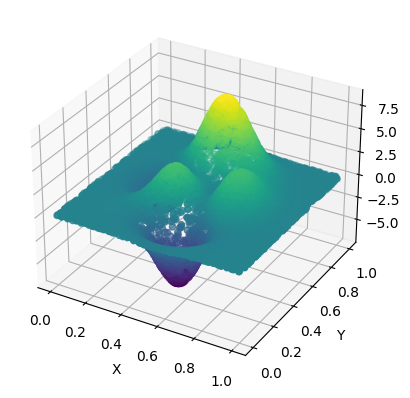

In [279]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Gráfico de dispersión 3D
ax.scatter(x0_test.numpy(), x1_test.numpy(), y_test.numpy(), c=y_test.numpy(), cmap='viridis', marker='o')

# Agregar etiquetas y título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Mostrar el gráfico
plt.show()

In [280]:
model_pred = ANFIStest_model_forSONFIS(torch.tensor(scaled_test))

In [281]:
ANFIStest_model_forSONFIS.consequents.data

tensor([[ 6.5745e-01,  2.5415e+00, -1.2079e+00],
        [ 1.3024e+07,  4.9228e+07, -2.3519e+07],
        [ 1.1545e+08,  4.3744e+08, -2.0888e+08]], dtype=torch.float64)

In [282]:
np_model_pred = model_pred.detach().numpy()

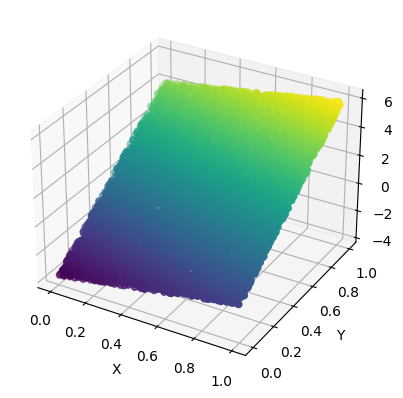

In [283]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Gráfico de dispersión 3D
ax.scatter(x0_test.numpy(), x1_test.numpy(), np_model_pred, c=np_model_pred, cmap='viridis', marker='o')

# Agregar etiquetas y título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Mostrar el gráfico
plt.show()

##Matlab Testing

#Problems Solving

## OLS nan results

```
pre OLS premises tensor([[[   6.5721,   66.5052],
         [  -3.7457,   46.4725],
         [-118.2714,   -8.7888],
         [-135.8490,   -8.7888]],

        [[ 587.8738, -310.5717],
         [ 834.7728, -149.1981],
         [1174.3099,   17.6522],
         [1209.6144,   17.6522]]], dtype=torch.float64)
pre OLS consequnets tensor([[ 0.6510,  2.4891, -1.2019],
        [ 0.6485,  2.4931, -1.2027],
        [ 0.8434,  0.7220,  0.2923],
        [ 0.7574,  0.7979,  0.6525]], dtype=torch.float64)

post OLS premises tensor([[[nan, nan],
         [nan, nan],
         [nan, nan],
         [nan, nan]],

        [[nan, nan],
         [nan, nan],
         [nan, nan],
         [nan, nan]]], dtype=torch.float64)
post OLS consequnets tensor([[ 0.6510,  2.4891, -1.2019],
        [ 0.6480,  2.4943, -1.2030],
        [    nan,     nan,     nan],
        [    nan,     nan,     nan]], dtype=torch.float64)
```



In [58]:
nan_test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 8)

In [59]:
x_trainset = nan_test_loader.dataset.tensors[0]
x_trainset

tensor([[0.5748, 0.4673],
        [0.6547, 0.7465],
        [0.6071, 0.9369],
        ...,
        [0.6870, 0.1857],
        [0.4420, 0.8397],
        [0.8605, 0.5555]], dtype=torch.float64)

In [60]:
nanANFIS = Type3ANFIS(x_trainset.shape[1], init_rules=1, x_train=x_trainset)

In [61]:
nan_premises = torch.tensor([[[   6.5721,   66.5052],
                              [  -3.7457,   46.4725],
                              [-118.2714,   -8.7888],
                              [-135.8490,   -8.7888]],

                             [[ 587.8738, -310.5717],
                              [ 834.7728, -149.1981],
                              [1174.3099,   17.6522],
                              [1209.6144,   17.6522]]], dtype=torch.float64)

nan_consequents = torch.tensor([[ 0.6510,  2.4891, -1.2019],
                                [ 0.6485,  2.4931, -1.2027],
                                [ 0.8434,  0.7220,  0.2923],
                                [ 0.7574,  0.7979,  0.6525]], dtype=torch.float64)

In [62]:
nanANFIS.set_premises(Parameter(nan_premises, requires_grad=True))
nanANFIS.set_consequents(Parameter(nan_consequents, requires_grad=True))

In [63]:
x_train = test_loader.dataset.tensors[0]
y_train = test_loader.dataset.tensors[1] #targets
new_consequents = torch.zeros_like(nanANFIS.consequents.data)
xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train
fls = nanANFIS.firing_levels(x_train) #firing_levels
print("fls",fls)

#iterates by rule
for i in range(nanANFIS.rules):
    #firing_levels diagonal matrix
    fls_diag = torch.diag(fls[:, i])
    print(f"fls_diag {i}",fls_diag)

    #new consequents
    new_consequents[i] = torch.inverse(xe.t() @ fls_diag @ xe) @ xe.t() @ fls_diag @ y_train

fls tensor([[1.6651e-01, 1.6143e-07, 0.0000e+00, 0.0000e+00],
        [1.6681e-01, 1.6311e-07, 0.0000e+00, 0.0000e+00],
        [1.6699e-01, 1.6429e-07, 0.0000e+00, 0.0000e+00],
        ...,
        [1.6625e-01, 1.5970e-07, 0.0000e+00, 0.0000e+00],
        [1.6686e-01, 1.6375e-07, 0.0000e+00, 0.0000e+00],
        [1.6666e-01, 1.6187e-07, 0.0000e+00, 0.0000e+00]], dtype=torch.float64,
       grad_fn=<ProdBackward1>)
fls_diag 0 tensor([[0.1665, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1668, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1670,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.1662, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.1669, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.1667]],
       dtype=torch.float64, grad_fn=<DiagEmbedBackward0>)
fls_diag 1 tensor([[1.6143e-07, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
      

_LinAlgError: linalg.inv: The diagonal element 1 is zero, the inversion could not be completed because the input matrix is singular.

##Consequents convergence

In [ ]:
ANFIStest_model_forSONFIS.consequents

In [ ]:
ANFIStest_model_forSONFIS.premises

In [ ]:
testing_consequents = torch.tensor([[ 70.7756,  2.3225, -14.2127],
                                    [ -62.7682, 20.3461, -1.2207],
                                    [ 0.5829,  82.3403,  19.2342],
                                    [ 10.7686,  8.3142, -52.2047]], dtype=torch.float64)

In [ ]:
ANFIStest_model_forSONFIS.set_consequents(Parameter(testing_consequents, requires_grad=True))

In [ ]:
ANFIStest_model_forSONFIS.consequents

In [ ]:
model_pred = ANFIStest_model_forSONFIS(torch.tensor(scaled_test))

In [ ]:
np_model_pred = model_pred.detach().numpy()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Gráfico de dispersión 3D
ax.scatter(x0_test.numpy(), x1_test.numpy(), np_model_pred, c=np_model_pred, cmap='viridis', marker='o')

# Agregar etiquetas y título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Mostrar el gráfico
plt.show()